# Laboratorio 5.2: Clasificación Binaria con PyTorch (KDD Cup 99)

**Dataset:** KDD Cup 99 — Detección de intrusiones de red  
**Tarea:** Predecir si una conexión es **normal (0)** o un **ataque (1)**.  
**Tipo de problema:** Clasificación binaria  


---
## Fase 1: Carga y Exploración del Dataset

El dataset contiene ~494 000 registros de tráfico de red (versión 10%) con 41 características.  
Las columnas categóricas (`protocol_type`, `service`, `flag`).

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
import os
%matplotlib inline

COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label'
]

df = pd.read_csv('../Datasets/2_kddcup/kddcup.data_10_percent',
                 header=None, names=COLUMNS)

df['label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)
for col in ['protocol_type', 'service', 'flag']:
    df[col] = pd.factorize(df[col])[0]

print(f"Filas × Columnas: {df.shape}")
print(f"Distribución de clases:\n{df['label'].value_counts()}")
df.head(3)


Filas × Columnas: (494021, 42)
Distribución de clases:
label
1    396743
0     97278
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,0,0,0,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0
1,0,0,0,0,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,0
2,0,0,0,0,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0


### 1.1 Visualización del balance de clases

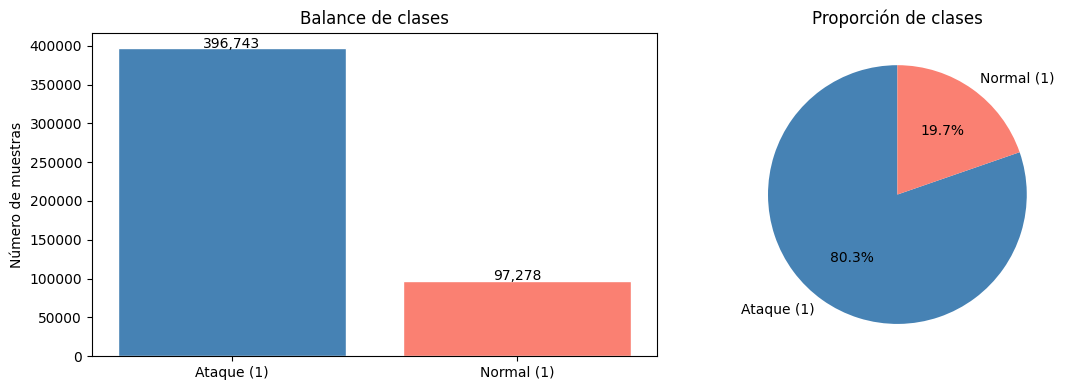

In [3]:
counts  = df['label'].value_counts()
labels_ = ['Ataque (1)', 'Normal (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels_, counts.values, color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Balance de clases'); axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

axes[1].pie(counts.values, labels=labels_, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporción de clases')
plt.tight_layout(); plt.show()


---
## Fase 2: Preprocesamiento y Split

In [4]:
X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.float32)

rng = np.random.default_rng(42)
idx = rng.permutation(len(X))

n_train = int(0.70 * len(X))
n_val   = int(0.15 * len(X))

idx_tr  = idx[:n_train]
idx_val = idx[n_train:n_train + n_val]
idx_te  = idx[n_train + n_val:]

X_tr,  y_tr  = X[idx_tr],  y[idx_tr]
X_val, y_val = X[idx_val], y[idx_val]
X_te,  y_te  = X[idx_te],  y[idx_te]

# Normalización (solo con media/std del train)
mean_X = X_tr.mean(axis=0)
std_X  = X_tr.std(axis=0) + 1e-8

X_tr  = (X_tr  - mean_X) / std_X
X_val = (X_val - mean_X) / std_X
X_te  = (X_te  - mean_X) / std_X

print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}")
print(f"Ataques en train: {y_tr.sum():.0f}/{len(y_tr)} ({100*y_tr.mean():.1f}%)")


Train: (345814, 41) | Val: (74103, 41) | Test: (74104, 41)
Ataques en train: 277794/345814 (80.3%)


---
## Fase 3: Dataset y DataLoader

In [5]:
class KDDDataset(Dataset):
    """Dataset KDD Cup para clasificación binaria."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 2048
train_ds = KDDDataset(X_tr,  y_tr)
val_ds   = KDDDataset(X_val, y_val)
test_ds  = KDDDataset(X_te,  y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape} | Batch y: {yb.shape}")


Batch X: torch.Size([2048, 41]) | Batch y: torch.Size([2048, 1])


---
## Fase 4: Modelo — MLP Clasificación Binaria

In [6]:
class MLPBin(nn.Module):
    """MLP para clasificación binaria (logit de salida)."""
    def __init__(self, in_features=41):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, 1)             # logit → aplica sigmoid
        )

    def forward(self, x): return self.net(x)

modelo = MLPBin(in_features=X_tr.shape[1])
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")
print(modelo)


Parámetros entrenables: 52,737
MLPBin(
  (net): Sequential(
    (0): Linear(in_features=41, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Fase 4.1: Entrenamiento

In [7]:
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS      = 30
LR          = 1e-3
BEST_PATH   = './checkpoints/kdd_best.pth'
RESUME_PATH = './checkpoints/kdd_resume.pth'
os.makedirs('./checkpoints', exist_ok=True)

modelo = MLPBin(in_features=X_tr.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.BCEWithLogitsLoss()

best_val_acc  = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, weights_only=False)
    modelo.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start_epoch  = ckpt['epoch'] + 1
    best_val_acc = ckpt['best_val_acc']
    history      = ckpt['history']
    print(f"▶ Reanudando desde época {start_epoch}")
else:
    start_epoch = 1
    print("▶ Entrenamiento desde cero.")

for epoch in range(start_epoch, EPOCHS + 1):
    modelo.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = modelo(xb)
        loss   = criterion(logits, yb)
        loss.backward(); optimizer.step()
        t_loss    += loss.item() * xb.size(0)
        preds      = (torch.sigmoid(logits) >= 0.5).float()
        t_correct += (preds == yb).sum().item()
        t_total   += yb.size(0)
    scheduler.step()

    modelo.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = modelo(xb)
            v_loss    += criterion(logits, yb).item() * xb.size(0)
            preds      = (torch.sigmoid(logits) >= 0.5).float()
            v_correct += (preds == yb).sum().item()
            v_total   += yb.size(0)

    tl = t_loss / t_total;  ta = 100 * t_correct / t_total
    vl = v_loss / v_total;  va = 100 * v_correct / v_total
    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);   history['val_acc'].append(va)

    if va > best_val_acc:
        best_val_acc = va
        torch.save(modelo.state_dict(), BEST_PATH)
        print(f"   ✓ Mejor modelo guardado (val_acc={va:.2f}%)")

    if epoch % 5 == 0:
        torch.save({'epoch': epoch, 'model_state': modelo.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'scheduler_state': scheduler.state_dict(),
                    'history': history, 'best_val_acc': best_val_acc}, RESUME_PATH)
        print(f"   💾 Backup (época {epoch}/{EPOCHS})")

    print(f"Epoch {epoch:3d}/{EPOCHS} | loss={tl:.4f} acc={ta:.2f}% | val_loss={vl:.4f} val_acc={va:.2f}%")

modelo.load_state_dict(torch.load(BEST_PATH, weights_only=True))
print(f"\n✅ Finalizado. Mejor val_acc: {best_val_acc:.2f}%")


▶ Reanudando desde época 31

✅ Finalizado. Mejor val_acc: 99.96%


### Fase 4.2: Curvas de entrenamiento

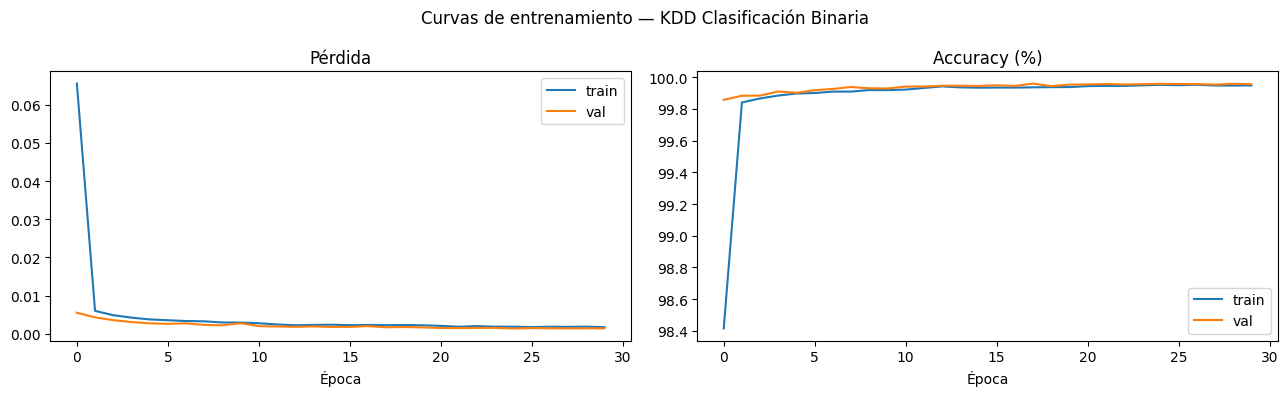

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Pérdida'); axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].plot(history['train_acc'], label='train'); axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.suptitle('Curvas de entrenamiento — KDD Clasificación Binaria')
plt.tight_layout(); plt.show()


---
## Fase 5: Guardar / Cargar Modelos

### 5.1 `state_dict` (recomendado)

In [9]:
torch.save(modelo.state_dict(), './checkpoints/kdd_demo.pth')
model_cargado = MLPBin(in_features=X_tr.shape[1])
model_cargado.load_state_dict(torch.load('./checkpoints/kdd_demo.pth', weights_only=True))
model_cargado.eval()
print("state_dict cargado ✓")


state_dict cargado ✓


### 5.2 Modelo completo

In [10]:
torch.save(modelo, './checkpoints/kdd_completo.pt')
model_full = torch.load('./checkpoints/kdd_completo.pt', weights_only=False)
model_full.eval()
print("Modelo completo cargado ✓")


Modelo completo cargado ✓


---
## Fase 6: Evaluación Final en Test

### 6.1 Accuracy, Precision, Recall, F1

In [11]:
from collections import Counter

best_model = MLPBin(in_features=X_tr.shape[1])
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.eval()
best_model.to(DEVICE)

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds  = (torch.sigmoid(logits) >= 0.5).cpu().numpy().astype(int).flatten()
        all_preds.extend(preds)
        all_true.extend(yb.numpy().astype(int).flatten())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

tp = ((all_preds == 1) & (all_true == 1)).sum()
tn = ((all_preds == 0) & (all_true == 0)).sum()
fp = ((all_preds == 1) & (all_true == 0)).sum()
fn = ((all_preds == 0) & (all_true == 1)).sum()

accuracy  = (tp + tn) / len(all_true) * 100
precision = tp / (tp + fp + 1e-8) * 100
recall    = tp / (tp + fn + 1e-8) * 100
f1        = 2 * precision * recall / (precision + recall + 1e-8)

print(f"✅ Accuracy : {accuracy:.2f}%")
print(f"   Precision: {precision:.2f}%")
print(f"   Recall   : {recall:.2f}%")
print(f"   F1-Score : {f1:.2f}%")


✅ Accuracy : 99.94%
   Precision: 99.96%
   Recall   : 99.96%
   F1-Score : 99.96%


### 6.2 Matriz de Confusión

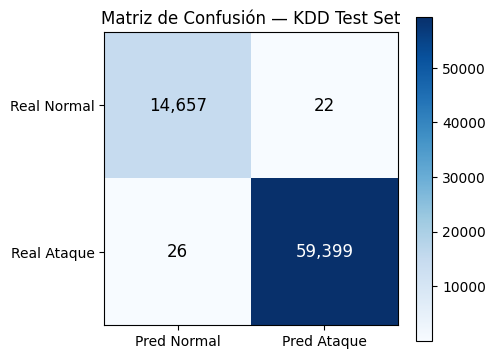

In [12]:
conf = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Normal', 'Pred Ataque'])
ax.set_yticklabels(['Real Normal', 'Real Ataque'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{conf[i, j]:,}', ha='center', va='center',
                color='white' if conf[i, j] > conf.max() / 2 else 'black', fontsize=12)
plt.colorbar(im); plt.title('Matriz de Confusión — KDD Test Set')
plt.tight_layout(); plt.show()


### 6.3 Predicción manual

Ingresa los datos de una conexión de red para predecir si es un ataque.

In [13]:
# Ejemplo: conexión normal (protocol=tcp=0, service=http=0, flag=SF=0)
conexion = [0, 0, 0, 0, 181, 5450, 0, 0, 0, 0, 0,
            1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8,
            8, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0,
            9, 9, 1.0, 0.0, 0.11, 0.0, 0.0, 0.0, 0.0, 0.0]

x_raw  = np.array([conexion], dtype=np.float32)
x_norm = (x_raw - mean_X) / std_X
x_in   = torch.tensor(x_norm, dtype=torch.float32).to(DEVICE)

best_model.eval()
with torch.no_grad():
    logit = best_model(x_in).item()
    prob  = torch.sigmoid(torch.tensor(logit)).item()

etiqueta = 'ATAQUE' if prob >= 0.5 else 'NORMAL'
print(f"Predicción: {etiqueta} | Probabilidad de ataque: {prob*100:.1f}%")


Predicción: NORMAL | Probabilidad de ataque: 0.1%
